# Data Exploration

Inspect the processed teammate telemetry and generate comparison plots for the selected team, session, and drivers.

## Team Selection

Choose the team, Grand Prix, and season that have already been processed. These parameters define the exact comparison window for the analysis.

In [7]:
team = "Aston Martin"
grand_prix = "Japanese Grand Prix"
year = 2025

## Imports and Configuration

Load dependencies, configure the notebook path, and prepare the modules used in the exploration steps.

In [8]:
import sys
import numpy as np
from pathlib import Path
import fastf1

project_root = Path.cwd().parent
sys.path.append(str(project_root))

from src import load_data, preprocess_data, explore_data

## Load Processed Data

Read the cached processed laps for both teammates so the notebook can work from already cleaned telemetry.

In [9]:
session = fastf1.get_session(year, grand_prix, "Q")
session.load()

driver_1, driver_2 = load_data.get_drivers(session, team)
segment = load_data.get_segment(session, driver_1, driver_2)
turns = load_data.get_turns(session)

try:
    lap_1, lap_2 = preprocess_data.load_processed_data(driver_1, driver_2, year, grand_prix, segment)
except Exception as e:
    print(f"Processed data for {year} {grand_prix} {driver_1} and {driver_2} not found: {e}")

core           INFO 	Loading data for Japanese Grand Prix - Qualifying [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '4', '81', '16', '63', '12', '6', '44', '23', '87', '10', '55', '14', '30', '22', '27', '5', '31', '7', '18']



Processed data for 2025 Japanese Grand Prix ALO and STR found in cache.
Driver 1: ALO, Driver 2: STR, Segment: Q1


## Basic Data Inspection

Review the interpolated telemetry structure, summary statistics, and a few sample rows before plotting.

In [10]:
print(f"\n{lap_1['Driver']} interpolated telemetry data info:\n")
print(lap_1['Interpolated'].info())
print(f"\n{lap_2['Driver']} interpolated telemetry data info:\n")
print(lap_2['Interpolated'].info())

print(f"{lap_1['Driver']} interpolated telemetry description:\n\n {lap_1['Interpolated'].describe()}")
print(f"\n{lap_2['Driver']} interpolated telemetry description:\n\n {lap_2['Interpolated'].describe()}")

print(f"\n{lap_1['Driver']} interpolated telemetry head:\n\n {lap_1['Interpolated'].head()}")
print(f"\n{lap_2['Driver']} interpolated telemetry head:\n\n {lap_2['Interpolated'].head()}")


ALO interpolated telemetry data info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 672 entries, 0 to 671
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Distance  672 non-null    float64
 1   Time      672 non-null    float64
 2   Speed     672 non-null    float64
 3   RPM       672 non-null    float64
 4   Throttle  672 non-null    float64
 5   nGear     672 non-null    int64  
 6   Brake     672 non-null    int64  
dtypes: float64(5), int64(2)
memory usage: 36.9 KB
None

STR interpolated telemetry data info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 672 entries, 0 to 671
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Distance  672 non-null    float64
 1   Time      672 non-null    float64
 2   Speed     672 non-null    float64
 3   RPM       672 non-null    float64
 4   Throttle  672 non-null    float64
 5   nGear     672 non-null    i

## Direct Variable Comparison

Compare selected telemetry variables visually and inspect the gap between the two teammates across the lap.

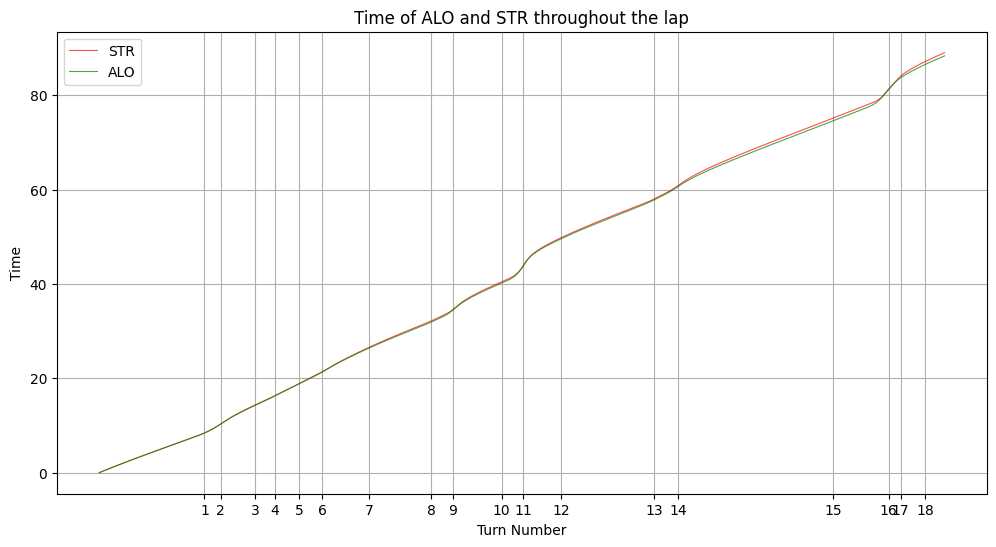

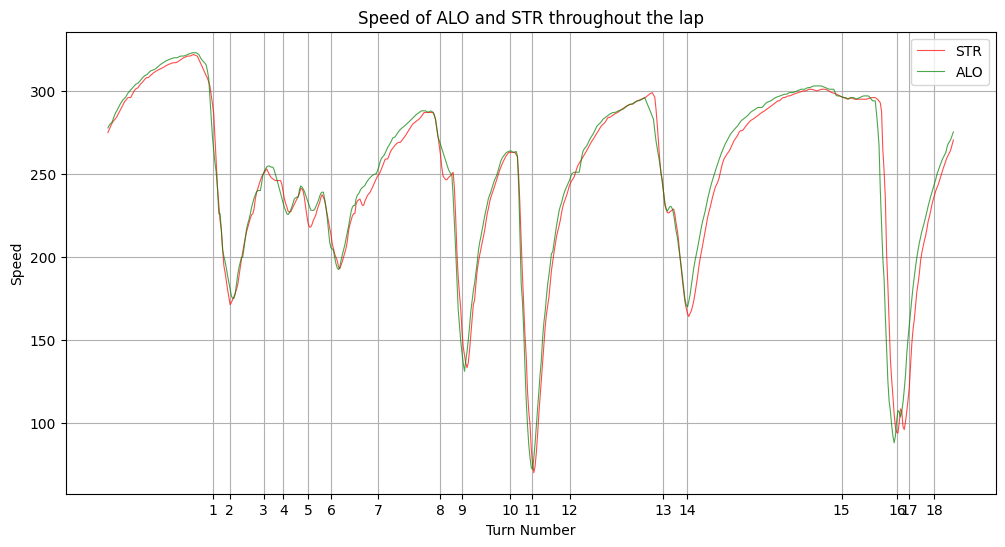

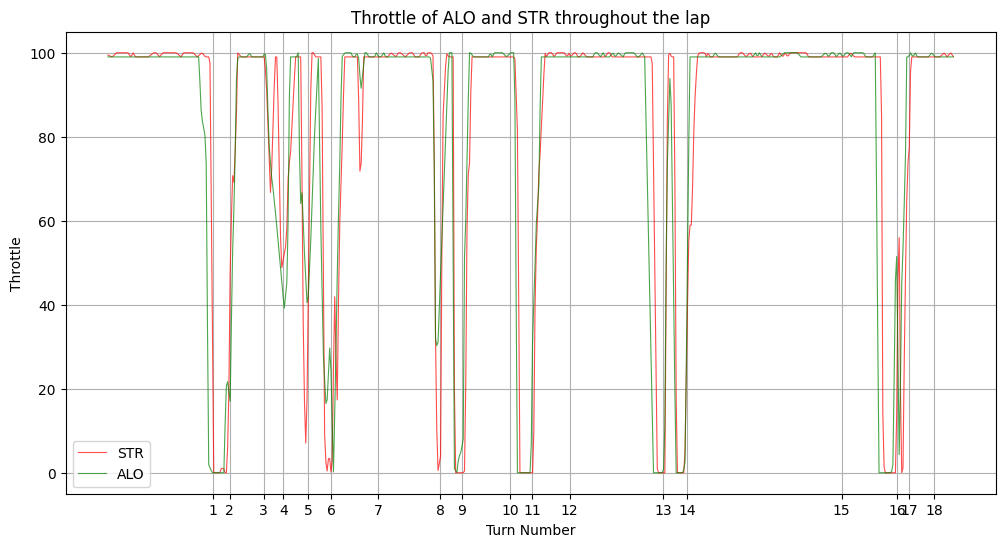

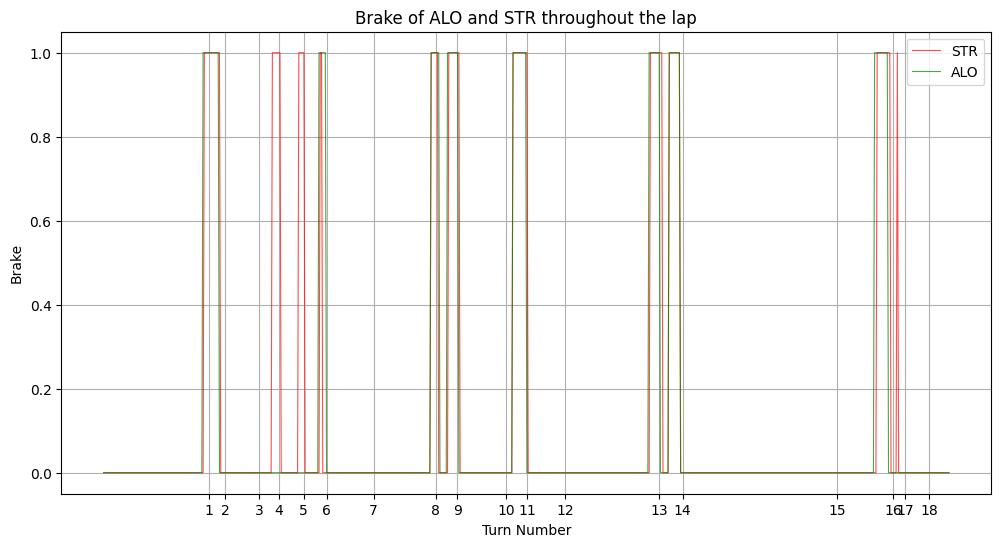

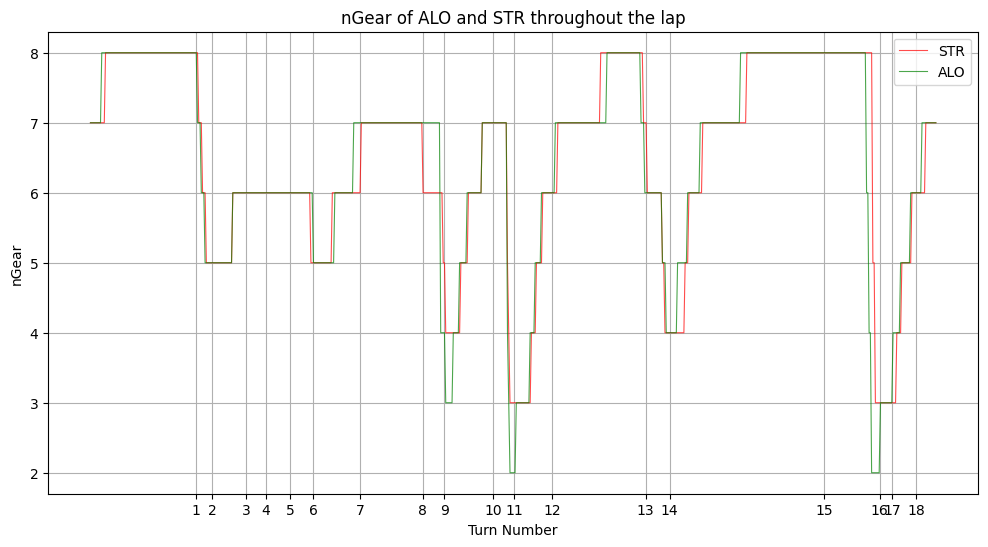

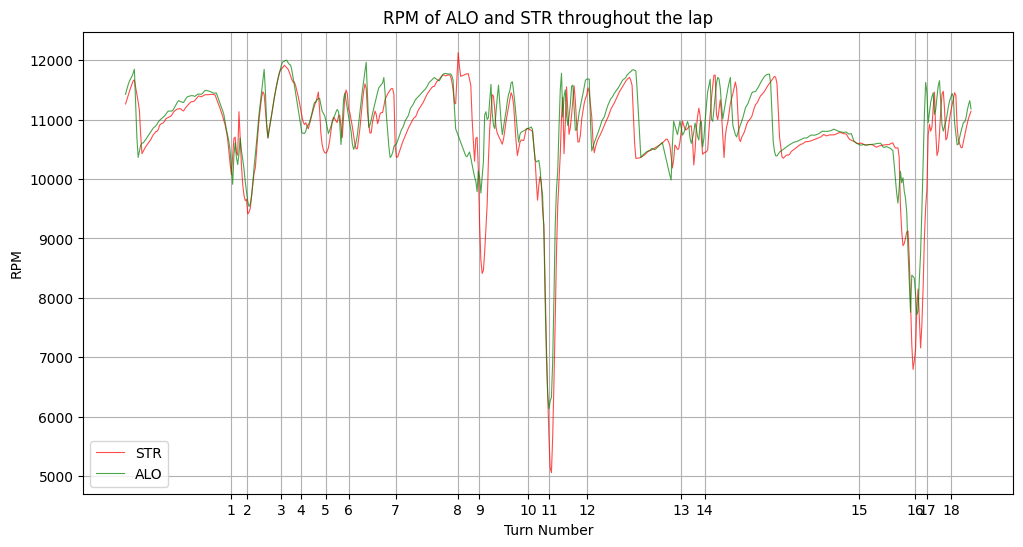

In [ ]:
for variable in ["Time", "Speed", "Throttle","Brake","nGear", "RPM"]:
    explore_data.plot_variable_comparison(lap_1["Interpolated"], lap_2["Interpolated"],variable, turns,  lap_1['Driver'])

## Delta of Variables

Plot the difference between the teammates for each selected telemetry variable.

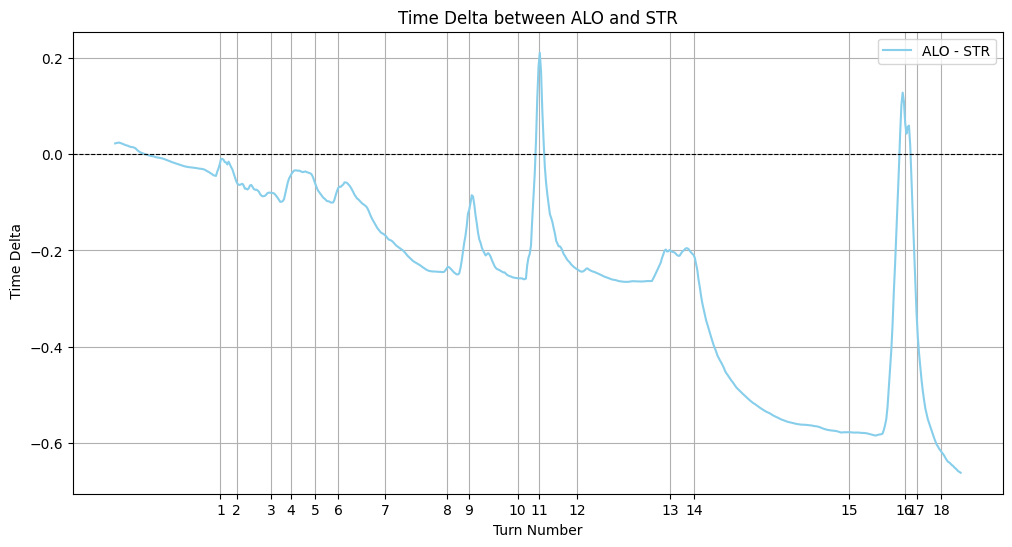

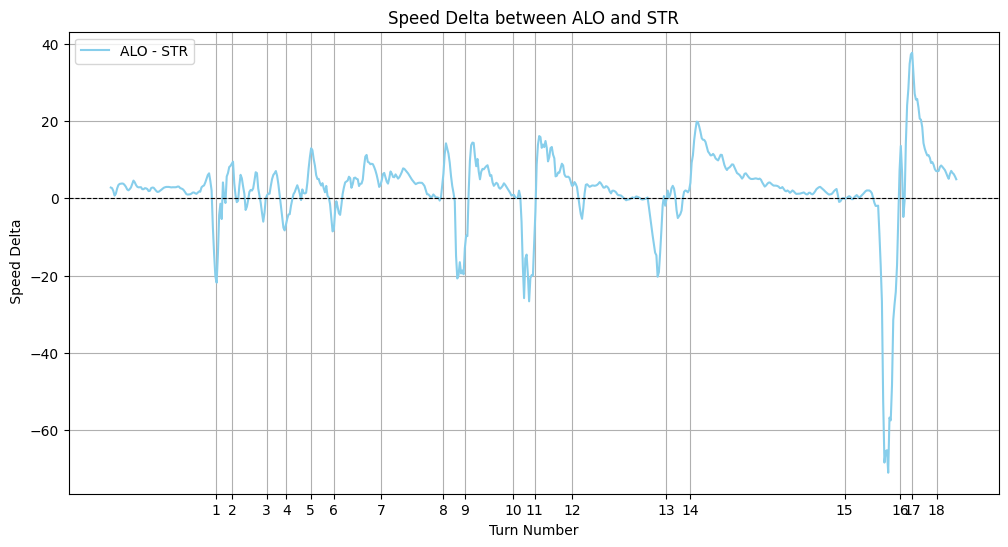

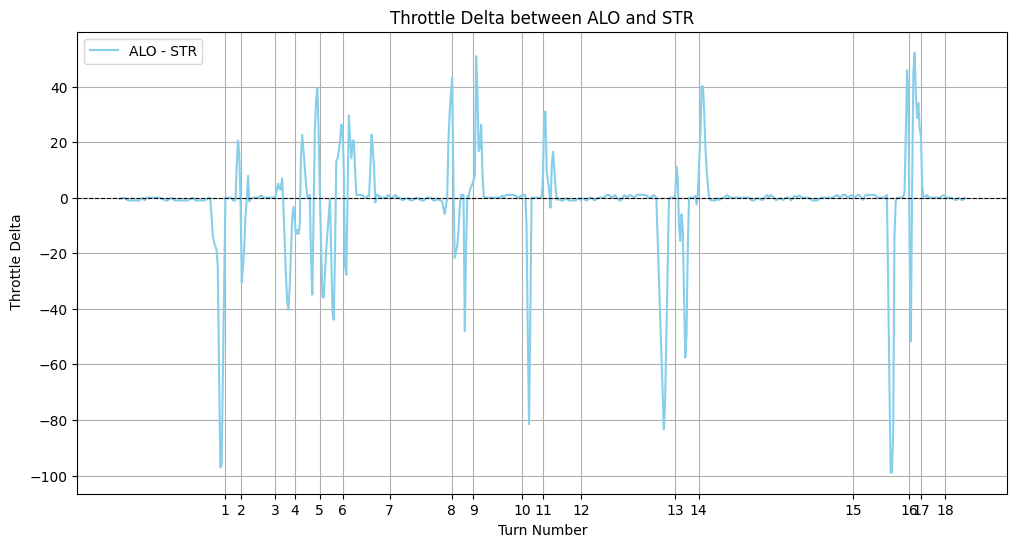

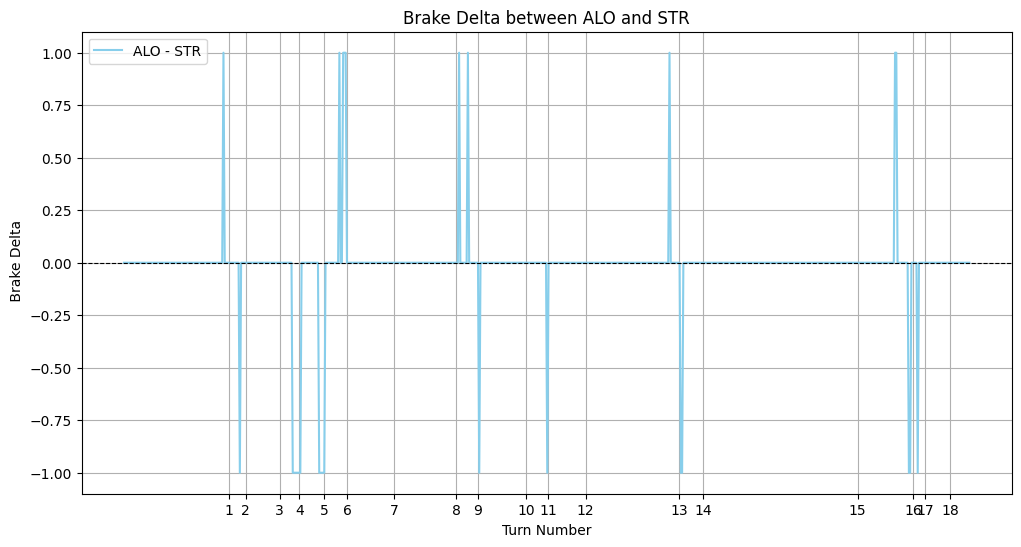

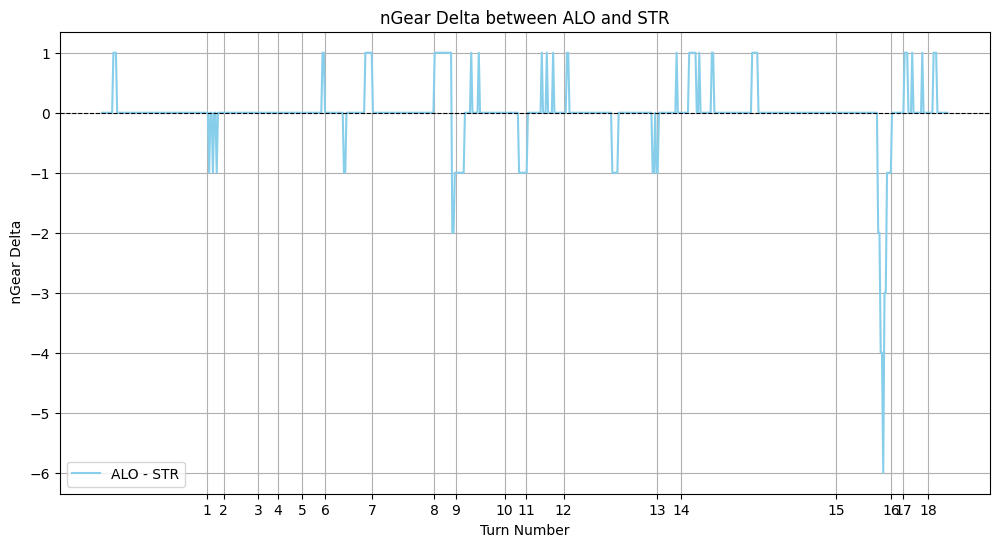

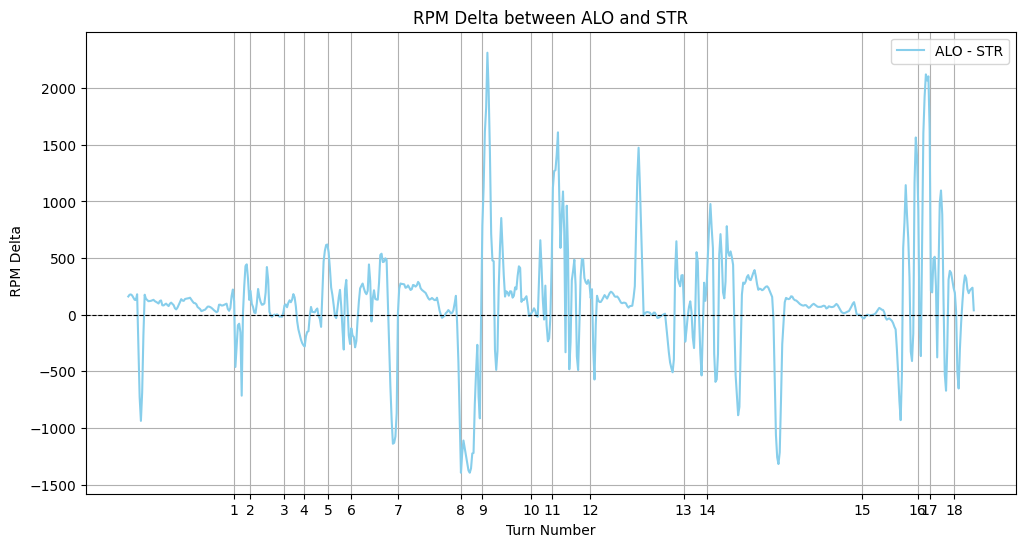

In [12]:
for variable in ["Time", "Speed", "Throttle","Brake","nGear", "RPM"]:
    explore_data.plot_variable_delta(lap_1["Interpolated"], lap_2["Interpolated"], lap_1['Driver'], lap_2['Driver'], variable, turns)